In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
df_index=pd.read_csv("economic_index.csv")

In [4]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


### Dropdonw unneccessary modal.

In [8]:
df_index.drop(columns=["Unnamed: 0", "year","month"],axis=1, inplace=True)

In [9]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [11]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

### Visulization 

In [12]:
import seaborn as sns

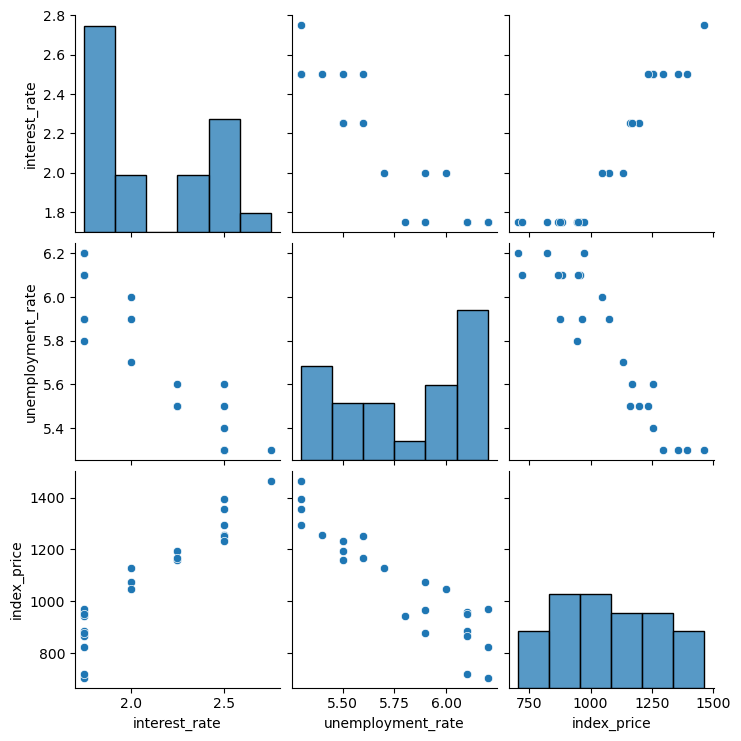

In [13]:
sns.pairplot(df_index)

In [14]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Um employment Rate')

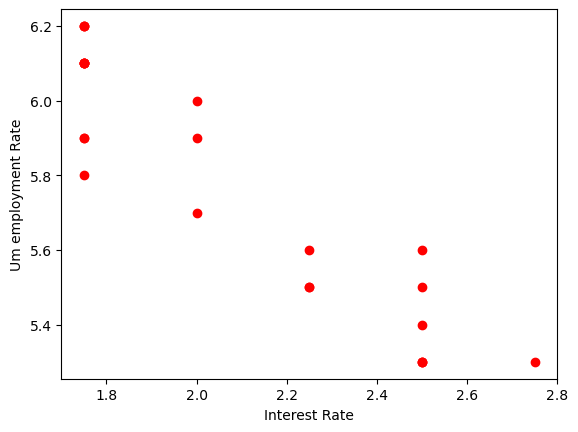

In [16]:
plt.scatter(df_index["interest_rate"], df_index["unemployment_rate"],color="r")
plt.xlabel("Interest Rate")
plt.ylabel("Um employment Rate")

## Dependent and Independent Features.

In [17]:
##independent and dependent features
X=df_index.iloc[:,:-1]
y=df_index.iloc[:,-1]

In [18]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [19]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

## train test split

In [21]:
from sklearn.model_selection import train_test_split


In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

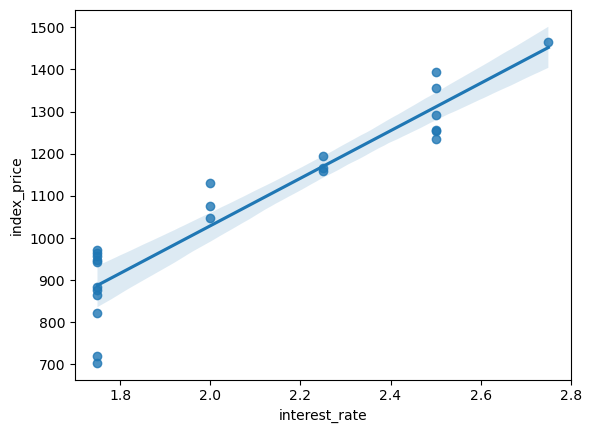

In [25]:
sns.regplot(x=df_index["interest_rate"], y=df_index["index_price"])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

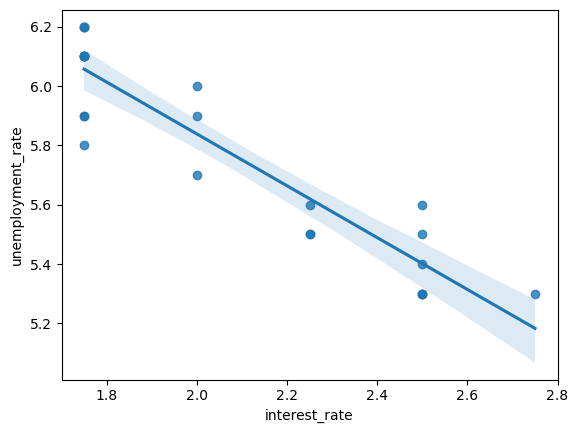

In [27]:
sns.regplot(x=df_index["interest_rate"], y=df_index["unemployment_rate"])

In [28]:
from sklearn.preprocessing import StandardScaler

In [30]:
scaler=StandardScaler()

In [31]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [35]:
from sklearn.linear_model import LinearRegression

In [36]:
regression = LinearRegression()

In [37]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## cross validation

In [38]:
from sklearn.model_selection import cross_val_score

In [39]:
validation_score=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [40]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [41]:
np.mean(validation_score)

np.float64(-5914.82818016239)

### Prediction 

In [42]:
y_pred=regression.predict(X_test)

In [43]:
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

## Performance Metrics

In [45]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

8108.567426306604
73.80444932337097
90.04758423359621


## R Score

In [47]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("R Squared : ",score)
#display adjusted R-squared
print("Adjusted R Squared : ",1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

R Squared :  0.7591371539010257
Adjusted R Squared :  0.5985619231683761


## Assumptions

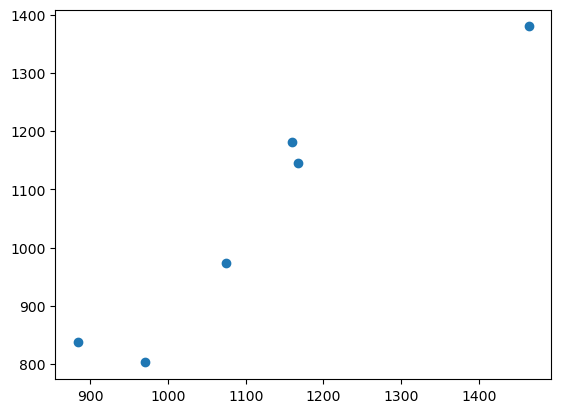

In [48]:
plt.scatter(y_test,y_pred)

In [49]:
residual = y_test - y_pred

In [50]:
residual

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64

### Plot Residual

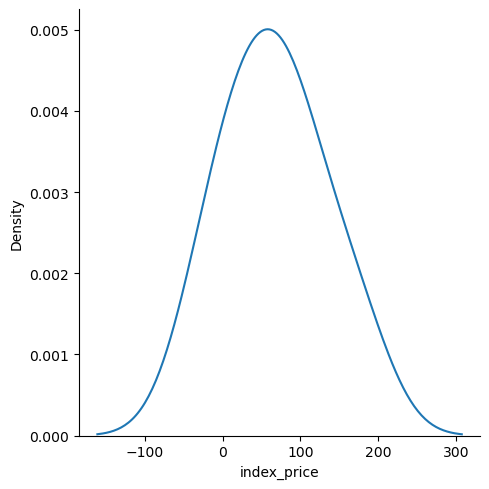

In [51]:
sns.displot(residual, kind="kde")

## scatter plot with respect to prediction and residuals

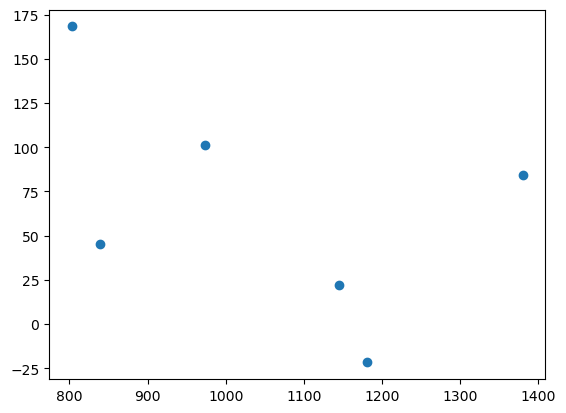

In [54]:
plt.scatter(y_pred,residual)

## OLS Linear Regression

In [55]:
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [56]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 05 Apr 2026   Prob (F-statistic):                       0.754
Time:                        15:13:08   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [59]:
print("Regression ", regression.coef_)


Regression  [  88.27275507 -116.25716066]
